# Testing Computation of Different Sizes of the Mandelbrot Set

## Import Libraries

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import time

## Functions to Test

In [2]:
def compute_mandelbrot_grid(x_region, y_region, max_iterations, bound, power):
    complex_number = 1j
    C = x_region + y_region * complex_number
    Z = np.zeros_like(C)
    M = np.zeros(C.shape, dtype=int)

    for _ in range(max_iterations):
        mask = np.abs(Z) <= bound
        Z[mask] = Z[mask]**power + C[mask]
        M[mask] += 1

    return M

# parameters
max_iterations = 100
bound = 2
power = 2

# regions
x_min, x_max = -2, 1
y_min, y_max = -1.5, 1.5


## Testing Size Scaling

Scale: 256
Computation took 0.05579 seconds!

Scale: 512
Computation took 0.29083 seconds!

Scale: 1024
Computation took 1.49652 seconds!

Scale: 2048
Computation took 5.95717 seconds!

Scale: 4096
Computation took 28.98233 seconds!



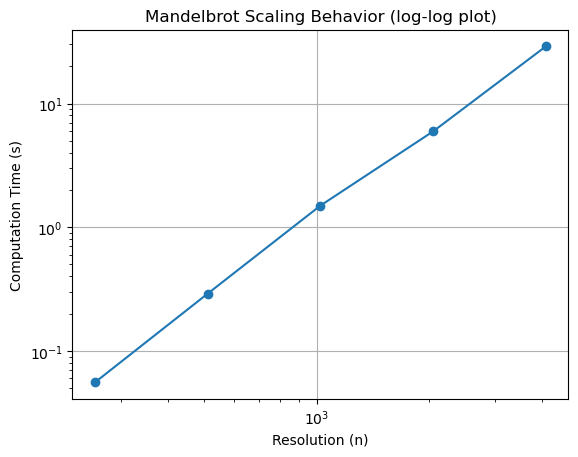

In [3]:
scales = [256, 512, 1024, 2048, 4096]

scale_test_times = []

for scale in scales:
    print(f'Scale: {str(scale)}')

    x_res, y_res = scale, scale

    x_values = np.linspace(x_min, x_max, x_res)
    y_values = np.linspace(y_min, y_max, y_res)
    x_region, y_region = np.meshgrid(x_values, y_values)

    # test time of computation
    start_time = time.perf_counter()
    mandelbrot_array = compute_mandelbrot_grid(x_region, y_region, max_iterations, bound, power)
    test_time = time.perf_counter() - start_time
    print(f'Computation took {test_time:.5f} seconds!\n')
    scale_test_times.append(test_time)

plt.figure()
plt.plot(scales, scale_test_times, marker='o')

plt.xscale('log') # downscaling scale
plt.yscale('log') # downscaling time

plt.xlabel('Resolution (n)')
plt.ylabel('Computation Time (s)')
plt.title('Mandelbrot Scaling Behavior (log-log plot)')

plt.grid(True)
plt.show()